In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import numpy as np
import sionna
# For link-level simulations
from sionna.phy.channel import OFDMChannel, CIRDataset
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.utils import ebnodb2no, PlotBER
from sionna.phy.ofdm import KBestDetector, LinearDetector

from sionna.phy.mimo import StreamManagement
from mitsuba import Point3f
# Import Sionna RT components
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver

###############################################################################

In [ ]:
# Global parameters
###############################################################################
F_C            = 3.5e9       # carrier [Hz]
CELL_SIZE      = (5., 5.)    # radio‑map grid [m]
SAMPLES_PER_TX = 2_000_000   # rays per Tx
MAX_DEPTH      = 5           # max reflections
FFT_SIZE       = 256
NUM_SYM        = 14
SUBC_SP        = 30e3        # subcarrier spacing [Hz]
BATCH_BER      = 512         # MC batch for BER
EBNO_DB        = 5.0         # Eb/N0 for BER curve
RX_REF_POS     = np.array([50., 50., 1.5])  # reference Rx

###############################################################################
# Scene helpers
###############################################################################

def make_scene(jam2_pos=None):
    """Return a Munich scene with Tx0 + Jam1 (+ optional Jam2)"""
    scene = load_scene(sionna.rt.scene.munich)
    scene.frequency = F_C

    # Common ULAs
    scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
    scene.rx_array = scene.tx_array

    # Serving base‑station
    scene.remove("tx0")  # remove default Tx0
    scene.add(Transmitter("tx0", position=[0., 0., 50.], power_dbm=43))

    # Static jammer
    scene.remove("jam1")  # remove default Jam1
    scene.add(Transmitter("jam1", position=[150., 80., 50.], power_dbm=30))
    
 
    # Mobile jammer (optional)
    if jam2_pos is not None:
        # unpack to built‑in floats
        x, y, z = map(float, jam2_pos)
        scene.remove("jam2")
        scene.add(
            Transmitter(
                "jam2",
                position=Point3f(x, y, z),
                power_dbm=30,
                velocity=Point3f(0.0, 0.0, 0.0)
            )
        )
    
    return scene

###############################################################################
# Radio‑map utilities
###############################################################################

def compute_radiomap(scene):
    rms = RadioMapSolver()
    rm  = rms(scene, cell_size=CELL_SIZE, max_depth=MAX_DEPTH,
              samples_per_tx=SAMPLES_PER_TX)
    return rm

###############################################################################
# BER for a single Rx position (RayTracingChannel, dynamic)
###############################################################################



###############################################################################
# Heat‑map generation
###############################################################################

def make_heatmaps():
    print(">>> Computing radio‑maps (no‑jam vs with‑jam)…")
    # --- (A) no‑jam ---------------------------------------------------------
    scene_no = make_scene(jam2_pos=None)
    rm_no    = compute_radiomap(scene_no)

    # --- (B) with jam (static+mobile at initial pos) ------------------------
    scene_j  = make_scene(jam2_pos=[-200., -100., 50.])
    rm_j     = compute_radiomap(scene_j)

    # RSS tensors ------------------------------------------------------------
    rss_sig_no = rm_no.rss[0]
    rss_sig_j  = rm_j.rss[0]
    rss_int_j  = np.max(rm_j.rss[1:], axis=0)  # max over 2 jammers
    

    # J/S heat‑map -----------------------------------------------------------
    js_map = rss_int_j - rss_sig_j
   
    plt.contour(js_map, levels=[0], colors="k")
    plt.savefig("js_heatmap.png", dpi=200)

    # SINR -------------------------------------------------------------------
    sinr_no = rm_no.sinr[0]
    sinr_j  = rm_j.sinr[0]
    delta   = sinr_j - sinr_no
    
    print(sinr_no.shape)
    print(sinr_no)
    print(sinr_j.shape)
    print(sinr_j)
    print(delta)
    # Plot SINR heat‑map
    plt.figure()
    plt.contourf(delta, levels=np.arange(-20, 31, 1), cmap="magma")
    plt.colorbar(label="SINR (dB)")
    plt.title("SINR with Jam (dB)")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.xlim(0, 200)
    plt.ylim(0, 200)
    


    rm_j.show(metric="sinr",     tx=0, vmin=-20, vmax=30)
    plt.savefig("sinr_nojam.png", dpi=200)
    # 如果想看「Receiver 永遠選 SINR 最佳的基地台」：
    
    rm_no.show(metric="sinr",     tx=0, vmin=-20, vmax=30)

    
    # CDF of the SINR for transmitter 0
    rm_no.cdf(metric="sinr", tx=0)
    rm_j.cdf(metric="sinr", tx=0)
    plt.savefig("delta_sinr.png", dpi=200)


###############################################################################
if __name__ == "__main__":
    tf.random.set_seed(1)
    np.random.seed(1)
    make_heatmaps()

    print("\nAll figures saved to current directory.")

In [ ]:
# ==============================================================
# 0) Imports & 全域設定
# ==============================================================

import os, sys, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from pathlib import Path
from scipy.linalg import eigh
from scipy.ndimage import uniform_filter, label

# Sionna / Sionna-RT
try:
    import sionna, sionna.rt
except ImportError:
    os.system("pip install -q sionna sionna-rt")
    import sionna, sionna.rt

from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       PathSolver, RadioMapSolver, subcarrier_frequencies)

np.set_printoptions(precision=3, suppress=True)
tf.get_logger().setLevel("ERROR")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ==============================================================
# 1) 參數區 -- 場景、天線、OFDM
# ==============================================================

SCENE_NAME  = sionna.rt.scene.etoile                # 3-D CAD 場景
CARRIER_F   = 30e9                                  # 30 GHz

# 陣列 (8×8 UPA)
ARRAY_CFG   = dict(num_rows=1, num_cols=1,
                   vertical_spacing = .5, horizontal_spacing = .5,
                   pattern="tr38901", polarization="V")

# Tx 列表 (name, pos xyz, ori rpy, role, power_dBm, velocity_xyz(m/s))
TX_LIST = [
  ("tx0",  [-100,-100,20], [np.pi*5/6,0,0], "desired", 40, [ 30,  0, 0]),
  ("tx1",  [-100,  50,20], [np.pi/6,  0,0], "desired", 40, [ 30,  0, 0]),
  ("tx2",  [ 100,-100,20], [-np.pi/2,0,0], "desired", 30, [  0,  0, 0]),
  ("jam1", [ 100,  50,20], [ np.pi/2,0,0], "jammer", 30, [-30,  0, 0]),
  ("jam2", [  50,  50,20], [ np.pi/3,0,0], "jammer", 30, [-30,  0, 0]),
  ("jam3", [ -50, -50,20], [ np.pi/3,0,0], "jammer", 30, [  0,  0, 0]),
]

RX_POS   = [0, 0, 50]                               # 1 台接收機 (可自行增加)

# PathSolver / RadioMap
PATHSOLVER_ARGS = dict(max_depth=5, los=True,
                       specular_reflection=True,
                       diffuse_reflection=False, refraction=True, seed=1)

RMSOLVER_ARGS   = dict(max_depth=5, cell_size=(1,1), samples_per_tx=1e7)

# OFDM
N_SC      = 1024
ΔF        = 30e3
N_SYM     = 1024
SYM_DUR   = 1/ΔF
DELAY_RES = SYM_DUR / N_SC          # 32 ns
DOP_RES   = ΔF / N_SYM              # 29 Hz

EBN0_dB   = 20

# CFAR & MUSIC 參數
CFAR_WIN      = 11                # 背景窗口
CFAR_THRESH_dB= 3                 # 門限
MUSIC_K       = 6                 # 預計路徑數 (噪聲子空間維度 = M−K)

# ==============================================================
# 2) 建立場景與 Tx/Rx
# ==============================================================

scene = load_scene(SCENE_NAME)
scene.tx_array = PlanarArray(**ARRAY_CFG)
scene.rx_array = PlanarArray(**ARRAY_CFG)

# 清空預設 Tx/Rx
for n in scene.transmitters.copy(): scene.remove(n)
for n in scene.receivers.copy():    scene.remove(n)

# 新增 Tx
for name,pos,ori,role,p_dbm,vel in TX_LIST:
    tx = Transmitter(name=name, position=pos, orientation=ori,
                     power_dbm=p_dbm);  tx.role = role; tx.velocity = vel
    scene.add(tx)

# 單一 Rx（要多 Rx 再自行複製）
rx = Receiver(name="rx0", position=RX_POS)
scene.add(rx)

# 索引表
tx_names = scene.transmitters
all_txs  = [scene.get(n) for n in tx_names]
idx_des  = [i for i,t in enumerate(all_txs) if t.role=="desired"]
idx_jam  = [i for i,t in enumerate(all_txs) if t.role=="jammer"]
M        = ARRAY_CFG["num_rows"]*ARRAY_CFG["num_cols"]     # 天線數

# ==============================================================
# 3) 求 CFR (帶時間演變)
# ==============================================================

solver = PathSolver()
freqs  = subcarrier_frequencies(N_SC, ΔF)

paths = solver(scene, **PATHSOLVER_ARGS)

H = paths.cfr(frequencies        = freqs,
              sampling_frequency = 1/SYM_DUR,
              num_time_steps     = N_SYM,
              normalize          = True,
              normalize_delays   = False,
              out_type           = "numpy")   # shape (1,RxAnt,Tx,TxAnt,T,F)
# squeeze & 調整成 (T,F,M) —— 這裡 Rx 只有 1 節點
H = H.squeeze()               # (T,F)
H = np.moveaxis(H, 0, 0)      # already (T,F)

RuntimeError: drjit.cuda.ad.TensorXf.__mul__(): jit_var_counter(): tried to create an array with 12884901888 entries, which exceeds the limit of 2^32 == 4294967296 entries.

TypeError: 'str' object cannot be interpreted as an integer

In [2]:
# ==============================================================
# 4) Delay–Doppler & CFAR 檢測干擾簇
# ==============================================================

# 先把所有天線平均 (做功率偵測就夠)
H_mean = H.copy()                             # 單天線就直接用
H_shift= np.fft.fftshift(H_mean, axes=1)
h_delay= np.fft.ifft(H_shift, axis=1, norm="ortho")
H_dd   = np.fft.fftshift(np.fft.fft(h_delay, axis=0,
                                   norm="ortho"), axes=0)
P_dd   = np.abs(H_dd)**2                     # (T,F) 功率圖 (歸一化)

# 背景平均 & CFAR
mu  = uniform_filter(P_dd, size=CFAR_WIN)
R_dB= 10*np.log10((P_dd+1e-12)/(mu+1e-12))
mask= (R_dB > CFAR_THRESH_dB)
mask = mask.astype(int)
L, n_comp = label(mask)                      # 連通域

print(f"Detected {n_comp} interference clusters")

# 每簇中心 (τ,ν)
delay_bins   = np.arange(N_SC)*DELAY_RES*1e9     # ns
doppler_bins = np.fft.fftshift(np.fft.fftfreq(N_SYM,d=SYM_DUR))

clusters=[]
for cid in range(1,n_comp+1):
    ys,xs = np.where(L==cid)
    τc_ns = delay_bins[xs].mean()
    νc_Hz = doppler_bins[ys].mean()
    clusters.append((cid,τc_ns,νc_Hz,ys,xs))
clusters.sort(key=lambda z:z[1])                # 依延遲排序

NameError: name 'uniform_filter' is not defined

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sionna.rt import (
    load_scene, PlanarArray, Transmitter, Receiver,
    PathSolver, subcarrier_frequencies
)

# 1) 参数区 ---------------------------------------------------
c0 = 3e8              # 光速 m/s
f0 = 28e9             # 28 GHz
SCENE = sionna.rt.scene.etoile
TX_ARRAY = dict(num_rows=1, num_cols=1,
                vertical_spacing=0.5, horizontal_spacing=0.5,
                pattern="iso", polarization="V")
RX_ARRAY = TX_ARRAY

# (name, pos, ori, role, power_dbm)
TX_LIST = [
    ("tx0",  [-50,  20, 20], [0,0,0], "desired", 30),
    ("jam1", [ 30, -10, 20], [0,0,0], "jammer",  30),
]

# OFDM / CFR 参数
N_SC      = 256
ΔF        = 30e3
SYM_DUR   = 1/ΔF
N_SYM     = 128

PATH_ARGS = dict(max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=42)

# 2) 场景 & 天线 ---------------------------------------------------
scene = load_scene(SCENE)
scene.frequency = f0
scene.tx_array  = PlanarArray(**TX_ARRAY)
scene.rx_array  = PlanarArray(**RX_ARRAY)

# 清空内置的 Tx/Rx
for n in scene.transmitters.copy(): scene.remove(n)
for n in scene.receivers.copy():    scene.remove(n)

# 创建 Tx
for name, pos, ori, role, p_dbm in TX_LIST:
    tx = Transmitter(name=name,
                     position=pos,
                     orientation=ori,
                     power_dbm=p_dbm)
    tx.role = role
    scene.add(tx)

# 创建 Rx
rx = Receiver("rx", position=[0,0,20])
scene.add(rx)

# 3) 求解 CIR -----------------------------------------------------
solver = PathSolver()
# 可以给 jammer 加速度模拟多普勒： 
# scene.get("jam1").velocity = [30,0,0]

paths = solver(scene, **PATH_ARGS)

# 抓每个 Tx→Rx 的 CIR：这里我们用 `paths.cir()`
# cir 返回一个对象，其中 .tau（ns），.a（复增益），.aoa（rad）、.aod ...
cir = paths.cir()

# : [#rx, #rx_ant, #tx, #tx_ant, #paths]
# a: [same shape]
# aoa: [same shape x 2维(az, el)]
print(cir.shape)
τ     = cir.tau      # 单位秒
α     = cir.a        # 复增益
aoa   = cir.aoa      # azimuth/elevation (rad)

# 只看 Rx 第0个天线，Tx 第n根，Tx天线第0根
τ     = τ[0,0,:,:,:]    # shape (Ntx, Npaths)
α     = α[0,0,:,:,:]
aoa_az = aoa[0,0,:,:,:][...,0]   # 取 azimuth

# 按 role 分 desired/jammer
tx_names = scene.transmitters
idx_des  = [i for i,n in enumerate(tx_names) if scene.get(n).role=="desired"]
idx_jam  = [i for i,n in enumerate(tx_names) if scene.get(n).role=="jammer"]

# 4) 在 jammer 的那些多径中，挑直射（最大增益）------------------------
# 这里假设「直射」时延最短，也是增益最大的那个簇
# 你也可以做 KMeans 在 (τ,|α|) 上聚类

# 把同一路径 |α| 求和得到总能量，然后选最大
energy = np.abs(α)**2   # (Ntx, Npaths)
# 先只看 jammer TX
Ejam = energy[idx_jam[0]]   # shape (Npaths,)
p0   = np.argmax(Ejam)
τ0   = τ   [idx_jam[0], p0]    # 直接径的时延 (s)
φ0   = aoa_az[idx_jam[0], p0]  # 直接径的到达角 (rad)

# 5) 将 τ0 → 距离 d, φ0 → 方位角 θ，反推 jammer XY ----------------
d0 = c0 * τ0          # 米
θ0 = φ0               # rad （假设水平面）

rx_xy = np.array(rx.position[:2])
jam_est = rx_xy + np.array([d0*np.cos(θ0),
                             d0*np.sin(θ0)])

print(f"=== Jammer 估计 ===\n"
      f" 时延  τ₀ = {τ0*1e9:.1f} ns  → d≈{d0:.1f} m\n"
      f" AoA   θ₀ = {np.rad2deg(θ0):.1f}°\n"
      f" 估计坐标 = [{jam_est[0]:.1f}, {jam_est[1]:.1f}]")

# 6) 画图：场景俯视 + 真值 vs 估计 ----------------------------------
# 先拿个俯视相机
cam = Camera(position=[0,0,500], look_at=[0,0,0])
scene.render(camera=cam,
             resolution=[800,800],
             radio_map=None,
             paths=None,
             clip_at=60)

# 在 matplotlib 里叠加点
fig = plt.gcf()
ax  = fig.axes[0]
# 真值
jam_true = np.array(scene.get("jam1").position[:2])
ax.scatter([jam_true[0]], [jam_true[1]],
           c='r', s=100, marker='x', label='True Jam')
# 估计
ax.scatter([jam_est[0]], [jam_est[1]],
           c='cyan', s=100, marker='o', label='Est. Jam')
ax.legend(loc='upper right')
plt.show()

# 7) （可选）Delay–Doppler 展示
#    如果你给了 jammer 速度，就能
#    paths.cfr(..., num_time_steps=N_SYM, sampling_frequency=1/SYM_DUR)
#    然后按前面教程转成 Delay–Doppler 且绘出 P(τ,ν)



AttributeError: 'tuple' object has no attribute 'shape'

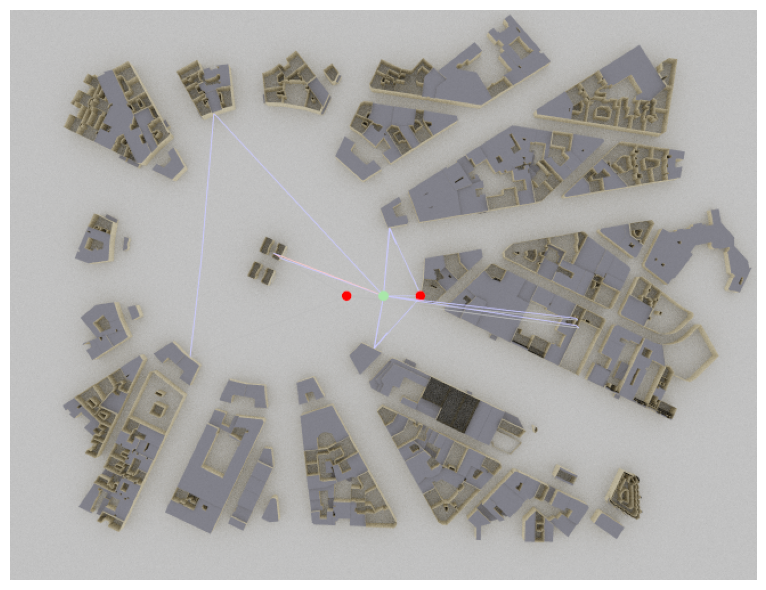

In [4]:
from sionna.rt import load_scene, Camera
my_cam = Camera(position=[0,0,1000], look_at=[0,1,0])
scene.render(camera=my_cam,paths=paths, clip_at=20) # Increase num_samples to increase image quality

In [3]:
# ==============================================================
# 5) MUSIC — 估 AoA  (以單 Rx 陣列為例)
# ==============================================================

def spatial_covariance(H_tf):
    """H_tf: (T,F,M) → (M,M)"""
    M = H_tf.shape[2]
    R = np.zeros((M,M), dtype=np.complex128)
    for t in range(T):          # T, F 稍大，可取子樣本加速
        for f in range(F):
            h = H_tf[t,f,:]     # (M,)
            R += np.outer(h, h.conj())
    return R / (T*F)

# 建 steering-vector
def steering_vec(az,el,layout):
    Nr,Nc = layout["num_rows"], layout["num_cols"]
    dx,dy = layout["horizontal_spacing"], layout["vertical_spacing"]
    k = 2*np.pi / (3e8/CARRIER_F)
    # 本例：x 水平, y 垂直, z 朝天
    m = np.arange(Nc) - (Nc-1)/2
    n = np.arange(Nr) - (Nr-1)/2
    M = []
    for ny in n:
        for mx in m:
            phase = k*(mx*dx*np.cos(el)*np.sin(az) +
                        ny*dy*np.sin(el))
            M.append(np.exp(1j*phase))
    return np.array(M)/np.sqrt(Nr*Nc)

# MUSIC 光譜
def music_spectrum(R, az_scan, el_fixed=0.0):
    vals,vecs = eigh(R)
    Un = vecs[:,:-MUSIC_K]           # 噪聲子空間
    spec=[]
    for az in az_scan:
        a = steering_vec(az, el_fixed, ARRAY_CFG)
        p = 1/np.abs(a.conj()@Un@Un.conj().T@a)
        spec.append(p)
    return np.array(spec)

# 估 AoA——對每個 cluster 計算其 (T0,F0) 能量峰，收集 M 天線向量
aoa_results=[]
az_scan = np.linspace(-np.pi, np.pi, 361)
for cid,τ_ns,ν_Hz,ys,xs in clusters:
    # 取該簇最大功率點
    t0,f0 = ys[P_dd[ys,xs].argmax()], xs[P_dd[ys,xs].argmax()]
    h_m   = H[t0,f0,:]                            # (M,)
    # 簡單估計：波束空間掃描 (Bartlett)
    P_bartlett = [np.abs(h_m @ steering_vec(az,0,ARRAY_CFG).conj())**2
                  for az in az_scan]
    az_est = az_scan[np.argmax(P_bartlett)]       # (弧度)
    aoa_results.append((cid, τ_ns, ν_Hz, np.rad2deg(az_est)))

In [4]:
# ==============================================================
# 6) Null-Steering  & BER 測試
# ==============================================================

# --- 6.1 Null-steer weight (MVDR)
def mvdr_null(des_az, jam_az_list):
    """返回 (M,) 權重，使 jammer 方位 null"""
    a_des = steering_vec(des_az,0, ARRAY_CFG)
    A_jam = np.stack([steering_vec(a,0,ARRAY_CFG) for a in jam_az_list], axis=1)
    # 投影到 jammer 子空間的正交補
    Pj = A_jam @ np.linalg.pinv(A_jam.conj().T @ A_jam) @ A_jam.conj().T
    w_tmp = (np.eye(M) - Pj) @ a_des
    return w_tmp / (a_des.conj().T @ w_tmp)

# (示範) 只 null 第一個簇
if len(aoa_results):
    jam_azs = [np.deg2rad(a[3]) for a in aoa_results]
    w  = mvdr_null(des_az=0.0, jam_az_list=jam_azs)
else:
    w  = np.ones(M)/M

# --- 6.2 產生資料 & BER
bits_tx = np.random.randint(0,2,(N_SC,2))
X_sym   = ((1-2*bits_tx[:,0]) + 1j*(1-2*bits_tx[:,1]))/np.sqrt(2)

def ber_from_H(H_tf, w=None):
    """單 OFDM symbol、單 Rx"""
    if w is not None:
        H_eff = (w.conj() @ H_tf.T).T            # (F,) 合成後 CFR
    else:
        H_eff = H_tf.mean(axis=1)                # M→1 (等權合)
    Y = X_sym * H_eff
    P_sig = np.mean(np.abs(Y)**2)
    N0    = P_sig/(10**(EBN0_dB/10)*2)
    noise = np.sqrt(N0/2)*(np.random.randn(*Y.shape)+1j*np.random.randn(*Y.shape))
    Y_rx  = Y + noise
    X_hat = Y_rx / (H_eff + 1e-12)
    bits_hat = np.stack([(X_hat.real<0).astype(int),
                         (X_hat.imag<0).astype(int)],axis=1)
    return (bits_hat!=bits_tx).mean()

BER_noJam = ber_from_H(H[...,0][None,:,:])          # 先拿第1根天線當例子
BER_wJam  = ber_from_H(H[...,0][None,:,:] + H_intf[np.newaxis,:])
BER_null  = ber_from_H(H, w=w)

print(f"BER  no-jam : {BER_noJam:.3e}")
print(f"BER with-jam: {BER_wJam :.3e}")
print(f"BER  null   : {BER_null :.3e}")

ValueError: operands could not be broadcast together with shapes (1,2,1024) (1024,2) 

TypeError: Invalid shape (6, 1024, 1024) for image data

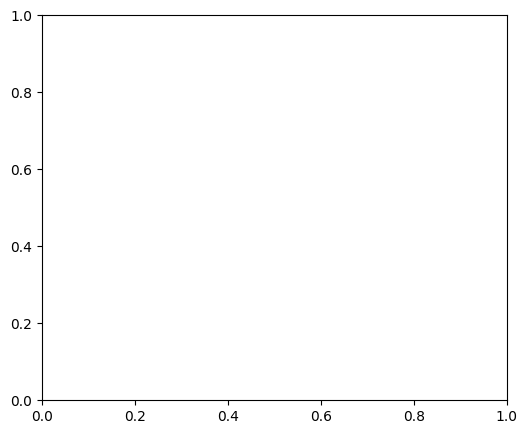

In [5]:
# ==============================================================
# 7) 視覺化
# ==============================================================

# 7.1 Delay–Doppler + 干擾簇標註
plt.figure(figsize=(6,5))
plt.imshow(R_dB, origin='lower', aspect='auto',
           extent=[delay_bins[0],delay_bins[-1],doppler_bins[0],doppler_bins[-1]],
           cmap='jet', vmin=-5, vmax=+5)
plt.colorbar(label='All/μ (dB)')
for cid,τ,ν,az in aoa_results:
    plt.plot(τ, ν, 'wx', ms=8, mew=2)
    plt.text(τ+50, ν+50, f'C{cid}\n{az:.0f}°', color='white',
             fontsize=8,bbox=dict(fc='k',alpha=.4))
plt.xlabel('Delay (ns)'); plt.ylabel('Doppler (Hz)')
plt.title('CFAR-Detected Jammer Clusters')
plt.tight_layout(); plt.show()